In [2]:
# ============================================================
# FRAUD DETECTION - COMPLETE MODEL TRAINING CODE
# ============================================================
# STEP 1: IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_score,
                             recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import pickle

In [4]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================
df = pd.read_csv('fraud_dataset_100k.csv')


print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

Shape: (100000, 10)
Columns: ['transaction_id', 'user_id', 'amount', 'transaction_type', 'merchant_category', 'country', 'hour', 'device_risk_score', 'ip_risk_score', 'is_fraud']

First 5 rows:
   transaction_id  user_id      amount transaction_type merchant_category  \
0           37735      780  131.745087           Online          Clothing   
1           68309      828   25.062371           Online       Electronics   
2           43561      106   17.664060              ATM            Travel   
3           29040      451  333.169032           Online           Grocery   
4           40176      947   12.450501           Online       Electronics   

  country  hour  device_risk_score  ip_risk_score  is_fraud  
0      NG     8           0.092460       0.187779         0  
1      US    19           0.240917       0.245637         0  
2      US    15           0.210105       0.279232         0  
3      FR    12           0.117781       0.292788         0  
4      FR    14           0.24171

In [5]:
# Checking the fraud counts and mean
print(df['is_fraud'].value_counts())
print(f"Fraud ratio: {df['is_fraud'].mean()*100:.2f}%")

is_fraud
0    95000
1     5000
Name: count, dtype: int64
Fraud ratio: 5.00%


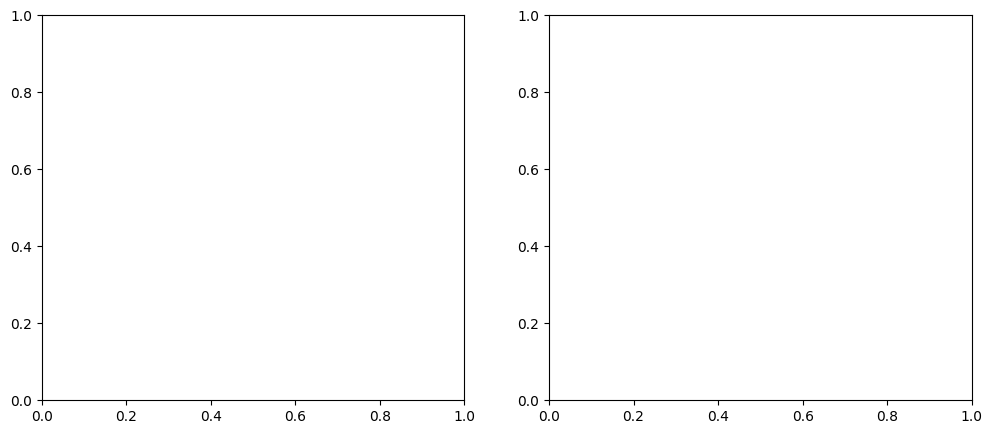

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

In [7]:

# Bar chart
df['is_fraud'].value_counts().plot(
    kind='bar', color=['green','red'], ax=axes[0])
axes[0].set_title('Transaction Distribution')
axes[0].set_xlabel('Class (0=Genuine, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Genuine', 'Fraud'], rotation=0)

[Text(0, 0, 'Genuine'), Text(1, 0, 'Fraud')]

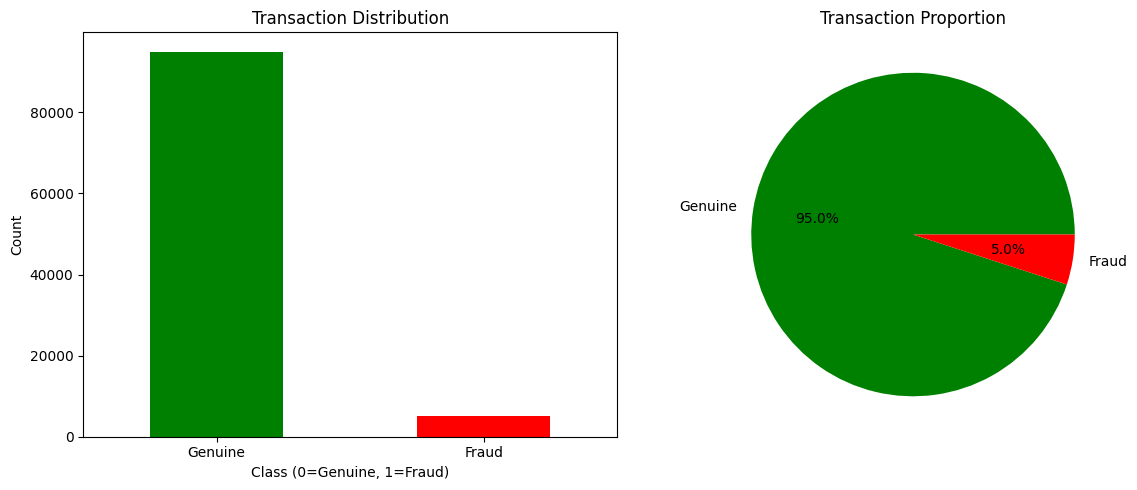

In [8]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['is_fraud'].value_counts().plot(
    kind='bar', color=['green','red'], ax=axes[0])
axes[0].set_title('Transaction Distribution')
axes[0].set_xlabel('Class (0=Genuine, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Genuine', 'Fraud'], rotation=0)

# Pie chart
axes[1].pie(
    [df['is_fraud'].value_counts()[0], df['is_fraud'].value_counts()[1]],
    labels=['Genuine', 'Fraud'],
    autopct='%1.1f%%',
    colors=['green', 'red']
)
axes[1].set_title('Transaction Proportion')

plt.tight_layout()
plt.show()

In [9]:
# STEP 4: FEATURE ENGINEERING
# 1. Encode categorical features
le_transaction = LabelEncoder()
le_merchant = LabelEncoder()
le_country = LabelEncoder()
df['transaction_type_enc'] = le_transaction.fit_transform(df['transaction_type'])
df['merchant_category_enc'] = le_merchant.fit_transform(df['merchant_category'])
df['country_enc'] = le_country.fit_transform(df['country'])
print(" Encoded transaction_type:", dict(zip(
    le_transaction.classes_,
    le_transaction.transform(le_transaction.classes_))))

print(" Encoded merchant_category:", dict(zip(
    le_merchant.classes_,
    le_merchant.transform(le_merchant.classes_))))

print(" Encoded country:", dict(zip(
    le_country.classes_,
    le_country.transform(le_country.classes_))))

 Encoded transaction_type: {'ATM': np.int64(0), 'Online': np.int64(1), 'POS': np.int64(2), 'QR': np.int64(3)}
 Encoded merchant_category: {'Clothing': np.int64(0), 'Electronics': np.int64(1), 'Food': np.int64(2), 'Grocery': np.int64(3), 'Travel': np.int64(4)}
 Encoded country: {'DE': np.int64(0), 'FR': np.int64(1), 'NG': np.int64(2), 'TR': np.int64(3), 'UK': np.int64(4), 'US': np.int64(5)}


In [10]:
df['is_night'] = ((df['hour'] <= 5) | (df['hour'] >= 22)).astype(int)
print(f"✅ Created 'is_night' feature")

# 3. Create HighAmount feature
df['is_high_amount'] = (df['amount'] > 1000).astype(int)
print(f"✅ Created 'is_high_amount' feature (threshold: $1000)")

✅ Created 'is_night' feature
✅ Created 'is_high_amount' feature (threshold: $1000)


In [11]:
# STEP 5: PREPARE FEATURES FOR MODEL
# Features for MODEL (NO risk scores!)
model_features = [
    'amount',
    'hour',
    'is_night',
    'is_high_amount',
    'transaction_type_enc',
    'merchant_category_enc',
    'country_enc'
]
target = 'is_fraud'

X = df[model_features].copy()
y = df[target].copy()

print(f"✅ Model features: {model_features}")
print(f"✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

✅ Model features: ['amount', 'hour', 'is_night', 'is_high_amount', 'transaction_type_enc', 'merchant_category_enc', 'country_enc']
✅ X shape: (100000, 7)
✅ y shape: (100000,)


In [12]:
# Step 6: Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")
print(f"✅ Frauds in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"✅ Frauds in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

✅ Training set: (80000, 7)
✅ Test set: (20000, 7)
✅ Frauds in train: 4000 (5.0%)
✅ Frauds in test: 1000 (5.0%)


In [13]:
# STEP 7: SCALE FEATURES
scaler = StandardScaler()
features_to_scale = ['amount', 'hour']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

print(f"✅ Scaled features: {features_to_scale}")
print("✅ Scaler fitted on training data only!")

✅ Scaled features: ['amount', 'hour']
✅ Scaler fitted on training data only!


In [14]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {y_train_smote.value_counts().to_dict()}")
print(f"✅ Training data balanced!")

Before SMOTE: {0: 76000, 1: 4000}
After SMOTE: {0: 76000, 1: 76000}
✅ Training data balanced!


In [15]:
# STEP 9: TRAIN 3 MODELS
# ============================================================
print("\n" + "="*60)
print("TRAINING MODELS")
print("="*60)

# Model 1: Logistic Regression
print("\n1️⃣  Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
print("✅ Logistic Regression trained!")

# Model 2: Decision Tree
print("\n2️⃣  Training Decision Tree...")
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train_smote, y_train_smote)
y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]
print("✅ Decision Tree trained!")

# Model 3: Random Forest
print("\n3️⃣  Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
print("✅ Random Forest trained!")



TRAINING MODELS

1️⃣  Training Logistic Regression...
✅ Logistic Regression trained!

2️⃣  Training Decision Tree...
✅ Decision Tree trained!

3️⃣  Training Random Forest...
✅ Random Forest trained!



📊 Logistic Regression
Accuracy:  0.9984
Precision: 0.9699
Recall:    1.0000 ⭐
F1-Score:  0.9847
ROC-AUC:   1.0000

Confusion Matrix:
  ✅ Frauds Caught (TP):    1000
  ❌ Frauds Missed (FN):    0
  ⚠️  False Alarms (FP):    31
  ✅ Correct Genuine (TN):  18969


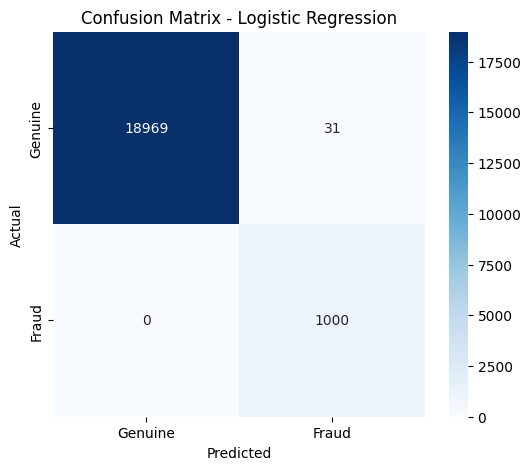


📊 Decision Tree
Accuracy:  0.9996
Precision: 0.9940
Recall:    0.9980 ⭐
F1-Score:  0.9960
ROC-AUC:   1.0000

Confusion Matrix:
  ✅ Frauds Caught (TP):    998
  ❌ Frauds Missed (FN):    2
  ⚠️  False Alarms (FP):    6
  ✅ Correct Genuine (TN):  18994


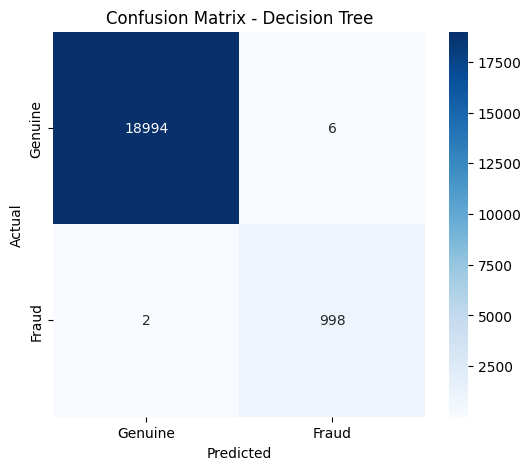


📊 Random Forest
Accuracy:  0.9994
Precision: 0.9911
Recall:    0.9980 ⭐
F1-Score:  0.9945
ROC-AUC:   1.0000

Confusion Matrix:
  ✅ Frauds Caught (TP):    998
  ❌ Frauds Missed (FN):    2
  ⚠️  False Alarms (FP):    9
  ✅ Correct Genuine (TN):  18991


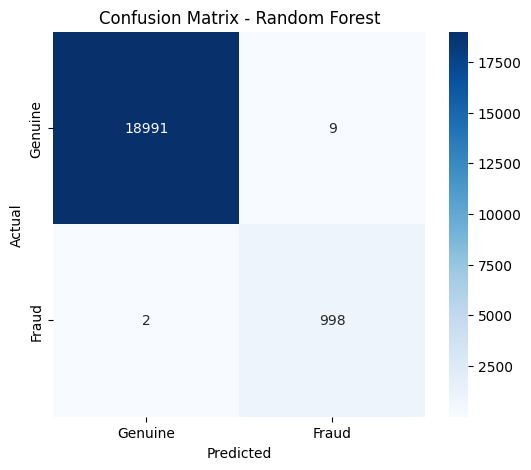

In [16]:
# STEP 10: EVALUATE ALL MODELS
def evaluate_model(y_true, y_pred, y_proba, model_name):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    print(f"\n{'='*60}")
    print(f"📊 {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {(TP+TN)/(TP+TN+FP+FN):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f} ⭐")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  ✅ Frauds Caught (TP):    {TP}")
    print(f"  ❌ Frauds Missed (FN):    {FN}")
    print(f"  ⚠️  False Alarms (FP):    {FP}")
    print(f"  ✅ Correct Genuine (TN):  {TN}")

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks([0.5, 1.5], ['Genuine', 'Fraud'])
    plt.yticks([0.5, 1.5], ['Genuine', 'Fraud'])
    plt.show()

    return {
        'Model': model_name,
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_lr, y_proba_lr, "Logistic Regression"))
results.append(evaluate_model(y_test, y_pred_dt, y_proba_dt, "Decision Tree"))
results.append(evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest"))


              Model  Precision  Recall  F1-Score  ROC-AUC   TP  FN
Logistic Regression   0.969932   1.000  0.984737 0.999987 1000   0
      Decision Tree   0.994024   0.998  0.996008 0.999995  998   2
      Random Forest   0.991063   0.998  0.994519 0.999969  998   2


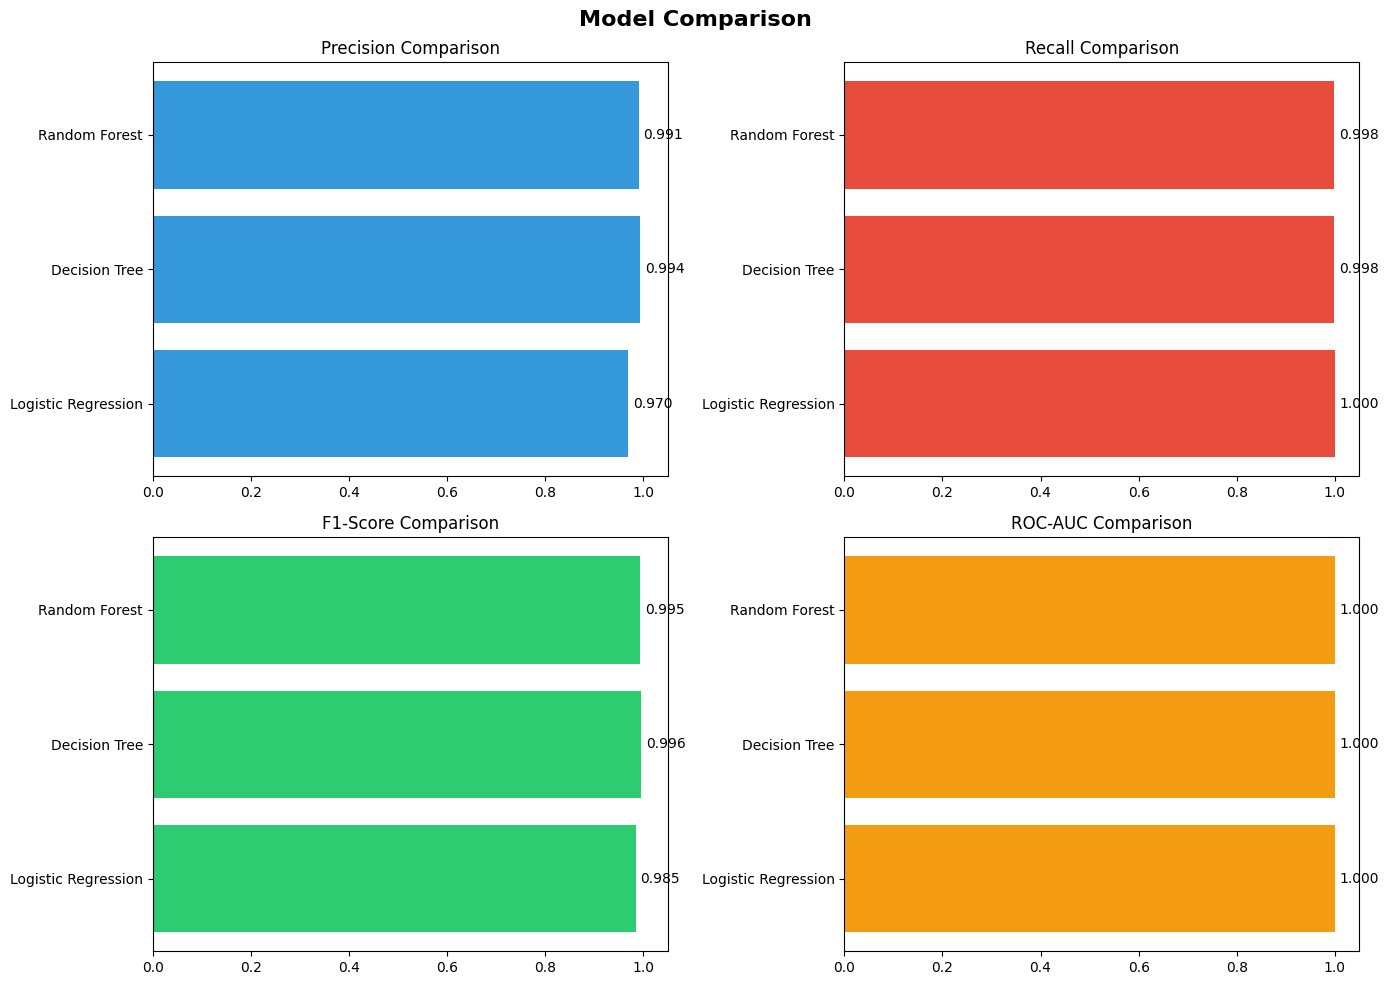

In [17]:
# Comparing all the models
comparison_df = pd.DataFrame(results)
print(comparison_df[['Model', 'Precision', 'Recall',
                      'F1-Score', 'ROC-AUC', 'TP', 'FN']].to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    axes[row, col].barh(
        comparison_df['Model'],
        comparison_df[metric],
        color=colors[idx]
    )
    axes[row, col].set_title(f'{metric} Comparison')
    axes[row, col].set_xlim([0, 1.05])
    for i, v in enumerate(comparison_df[metric]):
        axes[row, col].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()


In [18]:
import pickle

# ============================================================
# SAVE EVERYTHING IN ONE FILE
# ============================================================
print("="*60)
print("SAVING COMPLETE MODEL PACKAGE")
print("="*60)

# Pack everything together
model_package = {
    'model': rf,                        # Random Forest model
    'scaler': scaler,                   # Feature scaler
    'le_transaction': le_transaction,   # Transaction type encoder
    'le_merchant': le_merchant,         # Merchant category encoder
    'le_country': le_country,           # Country encoder
    'features': model_features,         # Feature names list
    'threshold': 0.5                    # Decision threshold
}

# Save to ONE file
pickle.dump(model_package, open('fraud_detection_complete.pkl', 'wb'))

print("✅ Everything saved in ONE file: fraud_detection_complete.pkl")
print("\n📦 Package contains:")
print("   🧠 Random Forest Model")
print("   📏 StandardScaler")
print("   🔤 Transaction Type Encoder")
print("   🔤 Merchant Category Encoder")
print("   🔤 Country Encoder")
print("   📋 Feature Names List")
print("   🎯 Decision Threshold (0.5)")


SAVING COMPLETE MODEL PACKAGE
✅ Everything saved in ONE file: fraud_detection_complete.pkl

📦 Package contains:
   🧠 Random Forest Model
   📏 StandardScaler
   🔤 Transaction Type Encoder
   🔤 Merchant Category Encoder
   🔤 Country Encoder
   📋 Feature Names List
   🎯 Decision Threshold (0.5)


In [19]:
print("\n" + "="*60)
print("TESTING THE SAVED PACKAGE")
print("="*60)

# Load it back
package = pickle.load(open('fraud_detection_complete.pkl', 'rb'))

# Extract everything
loaded_model = package['model']
loaded_scaler = package['scaler']
loaded_le_transaction = package['le_transaction']
loaded_le_merchant = package['le_merchant']
loaded_le_country = package['le_country']

print("✅ Package loaded successfully!")


TESTING THE SAVED PACKAGE
✅ Package loaded successfully!
